In [2]:
import nfl_data_py as nfl
import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

logos = nfl.import_team_desc()

logos.head()

logos = logos[['team_name', 'team_logo_espn']]

logos

logo_paths = []
team_name = []

if not os.path.exists("logos"):
    os.makedirs("logos")

In [3]:
for team in range(len(logos)):
    urllib.request.urlretrieve(logos['team_logo_espn'][team], f"logos/{logos['team_name'][team]}.tif")
    logo_paths.append(f"logos/{logos['team_name'][team]}.tif")
    team_name.append(logos['team_name'][team])

In [4]:
# Create a dictionary to put logo_paths and team_abbr in
data = {'Team Name' : team_name, 'Logo Path' : logo_paths}

# Create a DataFrame from the dictionary
logo_df = pd.DataFrame(data)

logo_df.head()

,Team Name,Logo Path
0,Arizona Cardinals,logos/Arizona Cardinals.tif
1,Atlanta Falcons,logos/Atlanta Falcons.tif
2,Baltimore Ravens,logos/Baltimore Ravens.tif
3,Buffalo Bills,logos/Buffalo Bills.tif
4,Carolina Panthers,logos/Carolina Panthers.tif


In [10]:
# print(os.getcwd())
df = pd.read_excel("Strength of Schedule for SB Teams.xlsx")
print(df.head())

                          Team  Strength of Schedule (teamrankings.com)  \
0  New England Patriots (2025)                                     -1.2   
1      Seattle Seahawks (2025)                                      1.8   
2    Kansas City Chiefs (2024)                                      1.2   
3   Philadelphia Eagles (2024)                                      0.4   
4    Kansas City Chiefs (2023)                                      2.0   

  Winner (Y/N)  Pts Scored  Year  
0            N          13  2025  
1            Y          29  2025  
2            N          22  2024  
3            Y          40  2024  
4            Y          25  2023  


In [11]:
df["Team"] = df["Team"].str.replace(r"\s*\(.*\)", "", regex=True)
df = df.rename(columns={"Team": "Team Name"})
team_ptsScored = df[['Team Name', 'Pts Scored', 'Strength of Schedule (teamrankings.com)', 'Year']]
team_ptsScored

,Team Name,Pts Scored,Strength of Schedule (teamrankings.com),Year
0,New England Patriots,13,-1.2,2025
1,Seattle Seahawks,29,1.8,2025
2,Kansas City Chiefs,22,1.2,2024
3,Philadelphia Eagles,40,0.4,2024
4,Kansas City Chiefs,25,2.0,2023
5,San Francisco 49ers,22,0.7,2023
6,Kansas City Chiefs,38,0.8,2022
7,Philadelphia Eagles,35,-0.3,2022
8,Los Angeles Rams,23,1.4,2021
9,Cincinnati Bengals,20,0.1,2021


In [12]:
vis_df1 = pd.merge(
    team_ptsScored,
    logo_df
)

vis_df1

,Team Name,Pts Scored,Strength of Schedule (teamrankings.com),Year,Logo Path
0,New England Patriots,13,-1.2,2025,logos/New England Patriots.tif
1,New England Patriots,13,0.3,2018,logos/New England Patriots.tif
2,New England Patriots,33,-0.3,2017,logos/New England Patriots.tif
3,New England Patriots,34,-0.2,2016,logos/New England Patriots.tif
4,New England Patriots,28,1.2,2014,logos/New England Patriots.tif
5,New England Patriots,17,0.2,2011,logos/New England Patriots.tif
6,New England Patriots,14,1.1,2007,logos/New England Patriots.tif
7,Seattle Seahawks,29,1.8,2025,logos/Seattle Seahawks.tif
8,Seattle Seahawks,24,1.6,2014,logos/Seattle Seahawks.tif
9,Seattle Seahawks,43,0.8,2013,logos/Seattle Seahawks.tif


In [13]:
def getImage(path):
    return OffsetImage(plt.imread(path, format="tif"), zoom=.1)


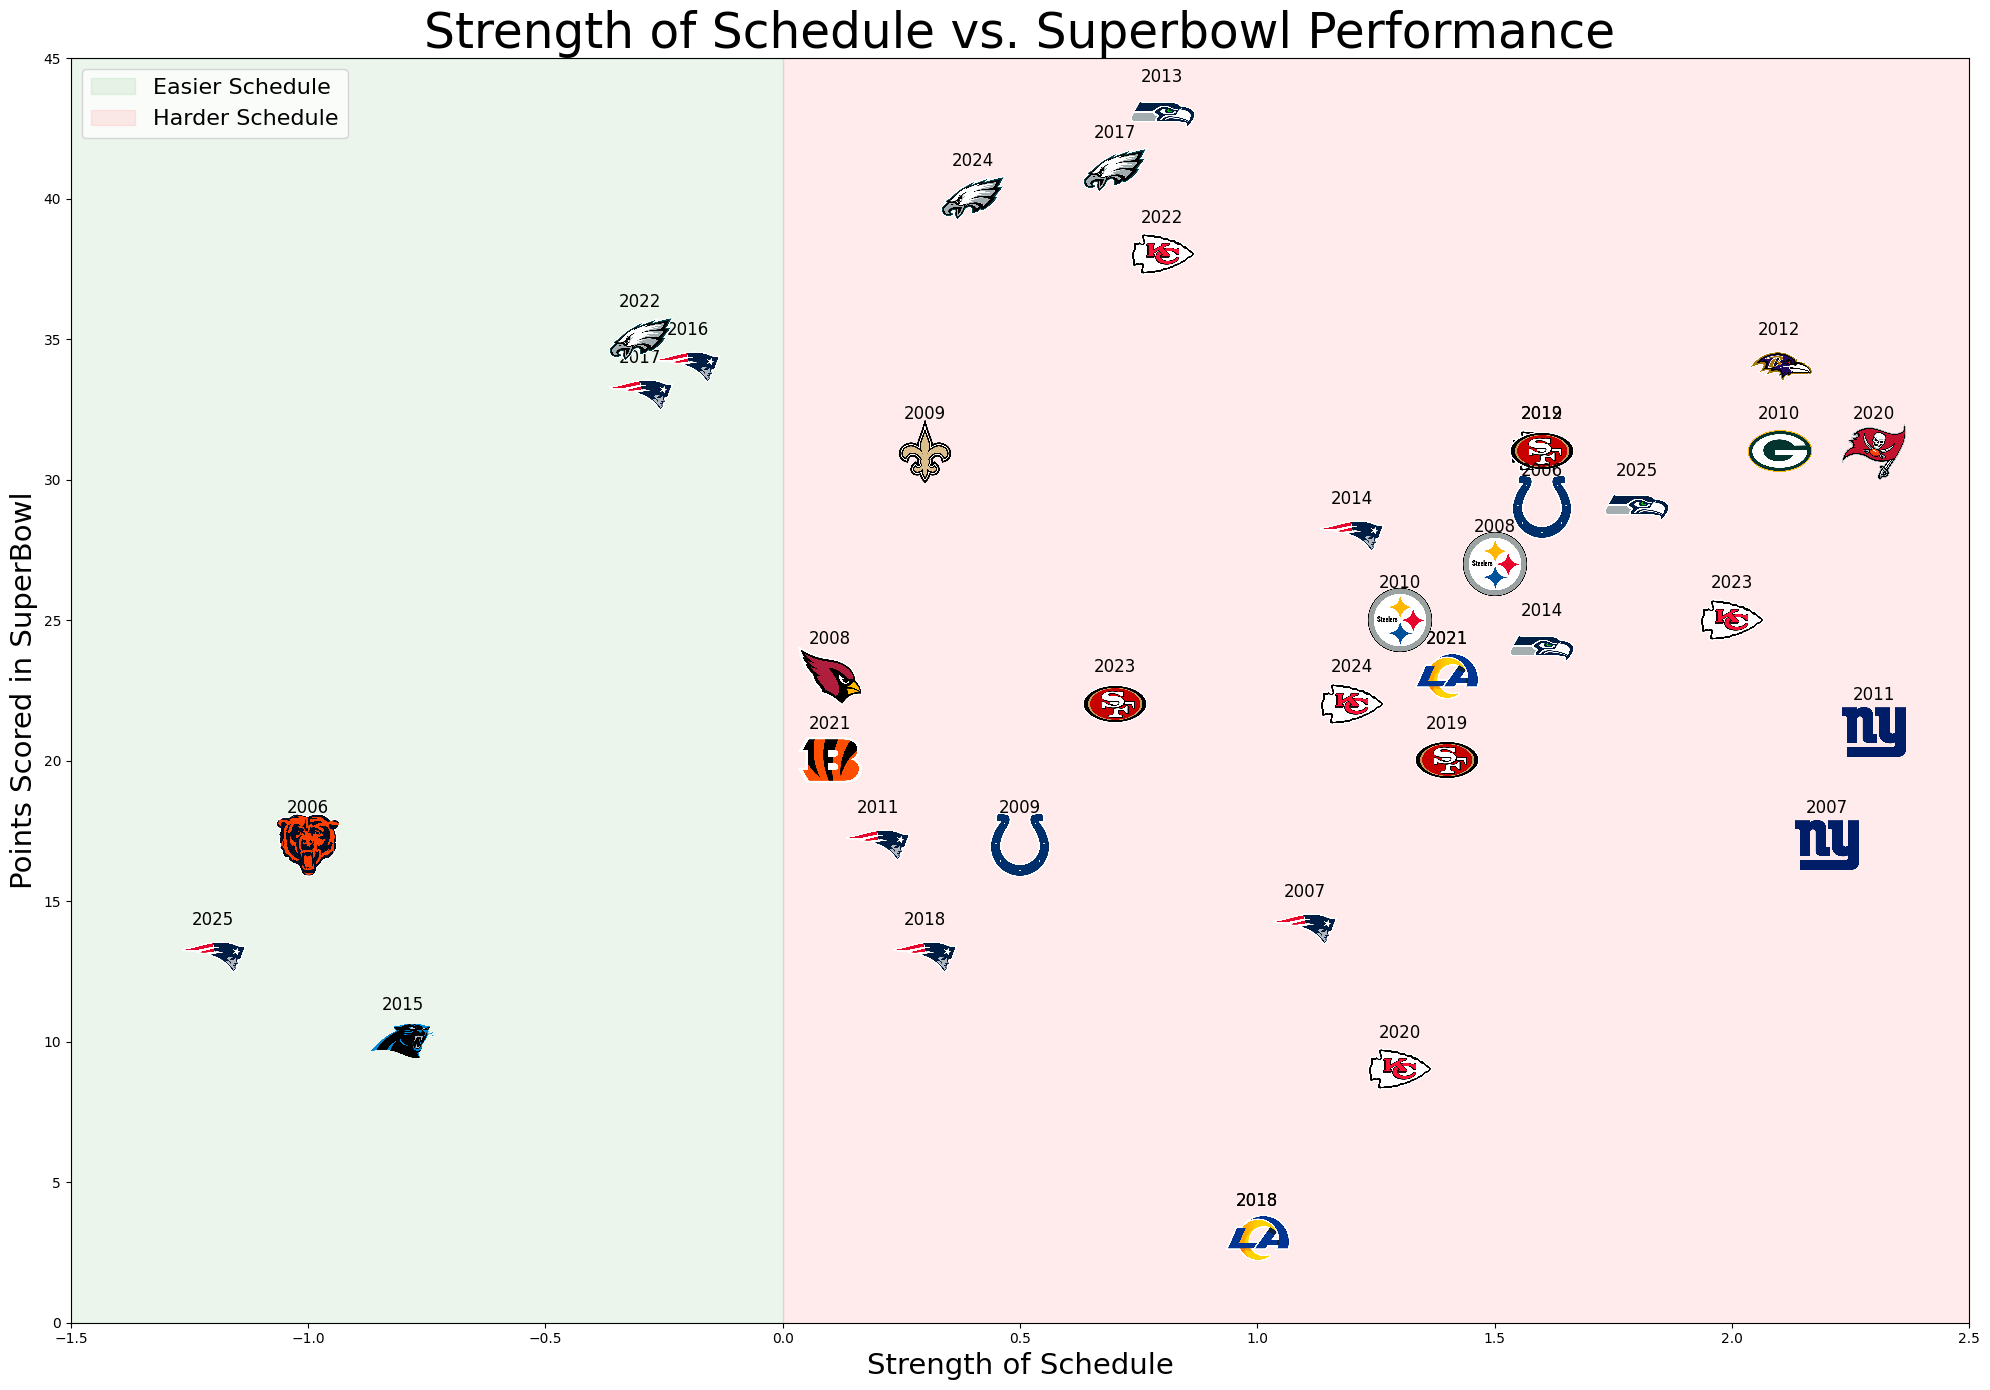

In [27]:
from matplotlib.patches import Patch

plt.rcParams["figure.figsize"] = [20, 14]
plt.rcParams["figure.autolayout"] = True

# Define the x and y variables
x = vis_df1['Strength of Schedule (teamrankings.com)']
y = vis_df1['Pts Scored']
years = vis_df1['Year']


# Define the image paths
paths = vis_df1['Logo Path']

# Define the plot
fig, ax = plt.subplots()


# Load the data into the plot
for x0, y0, path, years in zip(x, y, paths, years):
   ab = AnnotationBbox(getImage(path), (x0, y0), frameon=False)
   ax.add_artist(ab)
   ax.text(x0, y0 + 1, str(years), fontsize=12, ha='center', va='bottom', color='black')


# Make room at the bottom
plt.subplots_adjust(bottom=0.18)

# Plot parameters
plt.xlim(-1.5, 2.5);
plt.ylim(0, 45);

# Get limits
xmin, xmax = ax.get_xlim()

# Shade easier (left side)
ax.axvspan(xmin, 0, color='green',alpha=0.08)

# Shade harder (right side)
ax.axvspan(0, xmax, color='red', alpha=0.08)

legend_elements = [
    Patch(color='green',alpha=0.08, label='Easier Schedule'),
    Patch(color='red', alpha=0.08, label='Harder Schedule')
]

ax.legend(handles=legend_elements, loc='upper left', fontsize=16)

plt.title("Strength of Schedule vs. Superbowl Performance", fontdict={'fontsize':35});
plt.xlabel("Strength of Schedule", fontdict={'fontsize':21});
plt.ylabel("Points Scored in SuperBowl", fontdict={'fontsize':21});